In [1]:
#Import modules
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import os
import scipy.stats as stats
import torch
import torchvision.transforms as transforms
from PIL import Image
import random

#Google Drive Folder Created
drive_directory = '/home/jovyan/data/Tutorial_data/scratch/GEE_test/roblar/S2/'
#List of file names with file path
drive_files = os.listdir(drive_directory)
print(drive_files)

#Dictionary where .tif file paths 
files_by_quarter = {}

#Loops through drive directory
for drive_files in os.listdir(drive_directory):
    try:
        #Finds the directories for each .tif file
        directories = [drive_directory+drive_files+'/SAT/'+tifs for tifs in os.listdir(drive_directory+drive_files+'/SAT')]
    
        #Appends the directories for each .tif file to a dictonary with the date as the key
        files_by_quarter[drive_files]=directories
        
    except FileNotFoundError:
        #If there are no .tif files for the drive_ directory, error message printed and continues to the next directory
        print(f"No .tif in Directory {drive_directory+drive_files+'/SAT'}. Skipping the directory.")
        continue

['2024-07-01', '2023-01-01', '2020-07-01', '2016-04-01', '2024-01-01', '2019-07-01', '2017-04-01', '2016-10-01', '2020-04-01', '2023-07-01', '2019-04-01', '2017-01-01', '2022-10-01', '2021-04-01', '2022-04-01', '2023-10-01', '2022-01-01', '2024-04-01', '2021-10-01', '2020-10-01', '2017-10-01', '2018-07-01', '2022-07-01', '2018-10-01', '2018-04-01', '2016-01-01', '2017-07-01', '2016-07-01', '2019-01-01', '2023-04-01', '2019-10-01', '2021-01-01', '2024-10-01', '2020-01-01', '2018-01-01', '2021-07-01']
No .tif in Directory /home/jovyan/data/Tutorial_data/scratch/GEE_test/roblar/S2/2016-04-01/SAT. Skipping the directory.
No .tif in Directory /home/jovyan/data/Tutorial_data/scratch/GEE_test/roblar/S2/2017-04-01/SAT. Skipping the directory.
No .tif in Directory /home/jovyan/data/Tutorial_data/scratch/GEE_test/roblar/S2/2016-10-01/SAT. Skipping the directory.
No .tif in Directory /home/jovyan/data/Tutorial_data/scratch/GEE_test/roblar/S2/2017-01-01/SAT. Skipping the directory.
No .tif in Dire

In [2]:
#Empty dictionary
all_damdata = {}

#Extract data from each file
for quarter, tifs in files_by_quarter.items():
    #Empty list
    data_quarter = []
    for tif in tifs:
    
        #Open the file with rasterio
        with rasterio.open(tif) as dataset:
            #Read the bands (Blue, Green, Red, Near-Infrared)
            #Read as float64 in order to apply the Nan Mask in next step
            blue_band = dataset.read(1).astype(np.float64)  # Blue band (Band 1)
            green_band = dataset.read(2).astype(np.float64) # Green band (Band 2)
            red_band = dataset.read(3).astype(np.float64)   # Red band (Band 3)
            nir_band = dataset.read(4).astype(np.float64)   # Near-Infrared band (Band 4)

            #Since some files do not cover the full region, apply a mask so they are ignored in median calculation
            mask = (blue_band == 0) & (green_band == 0) & (red_band == 0) & (nir_band == 0)
            blue_band[mask] = np.nan
            green_band[mask] = np.nan
            red_band[mask] = np.nan
            nir_band[mask] = np.nan
        
            #Stack the bands as a 4D array
            file_data = np.stack([blue_band, green_band, red_band, nir_band], axis=-1)
        
            #Append file data to the data_quarter list
            data_quarter.append(file_data)

    #Convert to numpy array
    data_quarter = np.array(data_quarter)

    #Median across all files per pixel ignoring masked values
    median_data = np.nanmedian(data_quarter, axis=0)

    #Using first file obtain the geospatial coordinates (Longitude and Latitude)
    with rasterio.open(tifs[0]) as sing_dataset:
        transform = sing_dataset.transform
        rows, cols = sing_dataset.height, sing_dataset.width

        #Create row and column indices
        row_indices, col_indices = np.meshgrid(np.arange(rows), np.arange(cols), indexing='ij')

       #Flatten the arrays so they are 1D for use in rasterio.transform.xy()
        row_indices_flat = row_indices.flatten()
        col_indices_flat = col_indices.flatten()

        #Convert row and column indices to spatial coordinates (Longitude and Latitude)
        lon, lat = rasterio.transform.xy(transform, row_indices_flat, col_indices_flat)

    #Flatten the arrays so they are 1D
    blue = median_data[:, :, 0].flatten()
    green = median_data[:, :, 1].flatten()
    red = median_data[:, :, 2].flatten()
    nir = median_data[:, :, 3].flatten()
  
    #Create dataframe containing pixel values and coordinates
    damdata = pd.DataFrame({
        'Longitude': lon,
        'Latitude': lat,
        'Blue': blue,
        'Green': green,
        'Red': red,
        'NIR': nir
    })


    #Converting from digital numbers to reflectance as done by: https://docs.sentinel-hub.com/api/latest/data/sentinel-2-l2a/#harmonize-values
    damdata.iloc[:, 2:6] = damdata.iloc[:, 2:6] / 10000

    all_damdata[quarter]=damdata

/tmp/ipykernel_428/2298160293.py:36: RuntimeWarning: All-NaN slice encountered
  median_data = np.nanmedian(data_quarter, axis=0)


In [3]:
#Sorts the dictionary all_damdata by assending date
ordered_damdata = {date: all_damdata[date] for date in sorted(all_damdata)}
#Displays the data for the first date
ordered_damdata[list(ordered_damdata.keys())[0]]

,Longitude,Latitude,Blue,Green,Red,NIR
0,102.849958,27.300026,0.02990,0.04360,0.04520,0.17380
1,102.850048,27.300026,0.02435,0.04130,0.03030,0.19010
2,102.850138,27.300026,0.02425,0.04215,0.03255,0.18720
3,102.850228,27.300026,0.02425,0.04215,0.03255,0.18720
4,102.850318,27.300026,0.03395,0.04910,0.05440,0.17575
...,...,...,...,...,...,...
2484215,102.949671,27.099971,0.03305,0.05260,0.04385,0.22310
2484216,102.949761,27.099971,0.03305,0.05260,0.04385,0.22310
2484217,102.949851,27.099971,0.03205,0.05000,0.04530,0.23010
2484218,102.949941,27.099971,0.02980,0.05280,0.04380,0.25860


In [4]:
#Add additional indexes to use all go from -1 to 1 with help from digital numbers to reflectance conversion
for date in ordered_damdata:

    #Normalized Difference Vegetation Index (NDVI) from: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/ndvi/
    #NDVI = (NIR - Red)/(NIR + Red)
    ordered_damdata[date]['NDVI'] = (ordered_damdata[date]['NIR'] - ordered_damdata[date]['Red']) / (ordered_damdata[date]['NIR'] + ordered_damdata[date]['Red'])
    #Normalized Difference Water Index (NDWI) from https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/ndwi/
    #NDWI = (Green - NIR)/(Green + NIR)
    ordered_damdata[date]['NDWI'] = (ordered_damdata[date]['Green'] - ordered_damdata[date]['NIR']) / (ordered_damdata[date]['Green'] + ordered_damdata[date]['NIR'])
    #Normalized Differences Suspended Sediment Index(NDSSI) from: https://iopscience.iop.org/article/10.1088/1755-1315/98/1/012058/pdf#:~:text=The%20equation%20to%20identify%20the,by%20the%20presence%20of%20SM.
    #NDSSI = (Blue - NIR)/(Blue + NIR)
    ordered_damdata[date]['NDSSI'] = (ordered_damdata[date]['Blue'] - ordered_damdata[date]['NIR']) / (ordered_damdata[date]['Blue'] + ordered_damdata[date]['NIR'])
    #Normalized Suspended Material Index (NSMI) from: https://iopscience.iop.org/article/10.1088/1755-1315/98/1/012058/pdf#:~:text=The%20equation%20to%20identify%20the,by%20the%20presence%20of%20SM.
    #NSMI = (Red + Green - Blue)/(Red + Green + Blue)
    ordered_damdata[date]['NSMI'] = (ordered_damdata[date]['Red'] + ordered_damdata[date]['Green'] - ordered_damdata[date]['Blue']) / (ordered_damdata[date]['Red'] + ordered_damdata[date]['Green'] + ordered_damdata[date]['Blue'])

    #Nan values are produced 163 for NSMI and 27 for NDSSI, they are set to zero as likely caused by a division by 0
    ordered_damdata[date].fillna(0, inplace=True)

In [5]:
#Shows the statistics of the data
damdata.describe()

,Longitude,Latitude,Blue,Green,Red,NIR,NDVI,NDWI,NDSSI,NSMI
count,2.484220e+06,2.484220e+06,2.484220e+06,2.484220e+06,2.484220e+06,2.484220e+06,2.484220e+06,2.484220e+06,2.484220e+06,2.484220e+06
mean,1.029000e+02,2.720000e+01,3.783257e-02,6.624137e-02,4.756752e-02,3.305771e-01,6.735056e-01,-5.872048e-01,-7.121810e-01,5.057928e-01
std,2.891432e-02,5.777679e-02,2.588561e-02,2.909741e-02,3.671408e-02,1.158105e-01,3.462294e-01,3.573299e-01,3.568589e-01,5.213160e-02
min,1.028500e+02,2.709997e+01,4.800000e-03,5.300000e-03,2.900000e-03,1.000000e-04,-9.912281e-01,-8.681840e-01,-9.503978e-01,-2.269807e-01
25%,1.028749e+02,2.714998e+01,2.560000e-02,5.050000e-02,2.730000e-02,2.894000e-01,6.858721e-01,-7.484401e-01,-8.668181e-01,4.801061e-01
50%,1.029000e+02,2.720000e+01,3.090000e-02,6.000000e-02,3.650000e-02,3.455000e-01,8.048436e-01,-7.048825e-01,-8.362684e-01,5.147247e-01
75%,1.029251e+02,2.725001e+01,4.020000e-02,7.310000e-02,5.280000e-02,3.961000e-01,8.556327e-01,-6.278586e-01,-7.696589e-01,5.406699e-01
max,1.029500e+02,2.730003e+01,1.073600e+00,1.108000e+00,1.041600e+00,1.150400e+00,9.454971e-01,9.959839e-01,9.932886e-01,7.896951e-01


In [6]:
#Shows there are no Nan values in the data (Done for the first date)
np.sum(np.isnan(ordered_damdata[list(ordered_damdata.keys())[0]]))

/opt/miniconda/envs/ml-env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Longitude    0
Latitude     0
Blue         0
Green        0
Red          0
NIR          0
NDVI         0
NDWI         0
NDSSI        0
NSMI         0
dtype: int64

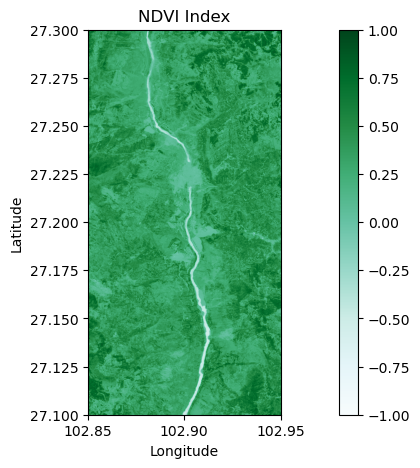

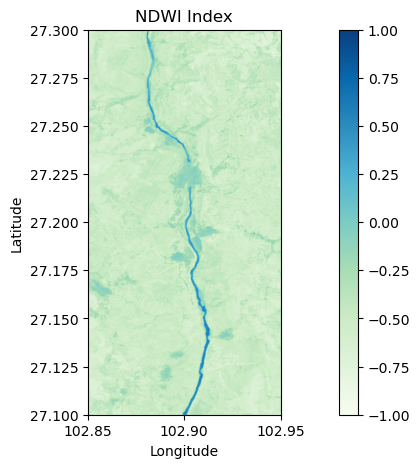

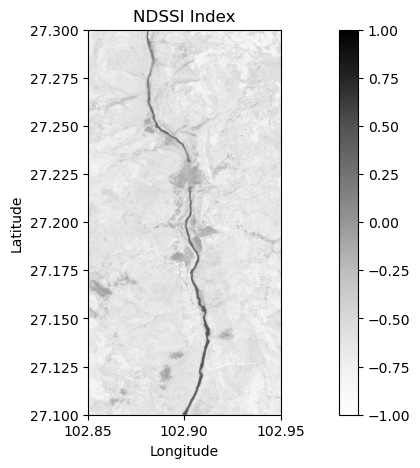

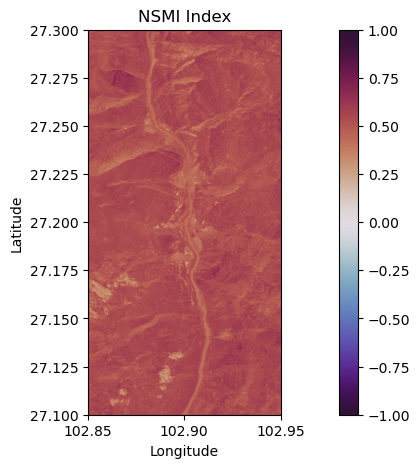

In [7]:
#Visualise the additional indexes

def plot_band(band_data, band_name, colour):
    """
    Plots a given band or index from the DataFrame.
    
    :param band_data: Flattened band or index data (1D array)
    :param band_name: The name of the band or index  (e.g., 'Blue' or 'NDVI')
    :param colour: The name of the cmap to display the data
    """
    
    #Define the extent for the plot
    extent = (102.85, 102.95, 27.10, 27.30)
    
    #Replace all zero values with a small positive number for logarithmic scaling
    band_data[band_data == 0.0] = np.min(band_data[band_data != 0])  #Replaces zero values with lowest non-zero in the data
    
    #Reshape to 2D from 1D
    band_reshaped = band_data.reshape(blue_band.shape)    
    
    #Plot the band or indexes
    plt.figure(figsize=(15, 5))
    plt.imshow(band_reshaped, cmap=colour, extent=extent, vmin=-1, vmax=1)
    plt.colorbar()
    plt.title(f'{band_name} Index')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

#Use the function to plot the desired band or index (Done for the first date)
plot_band(ordered_damdata[list(ordered_damdata.keys())[0]]['NDVI'].values, 'NDVI', 'BuGn')
plot_band(ordered_damdata[list(ordered_damdata.keys())[0]]['NDWI'].values, 'NDWI', 'GnBu')
plot_band(ordered_damdata[list(ordered_damdata.keys())[0]]['NDSSI'].values, 'NDSSI', 'Greys')
plot_band(ordered_damdata[list(ordered_damdata.keys())[0]]['NSMI'].values, 'NSMI', 'twilight_shifted')

2018-01-01


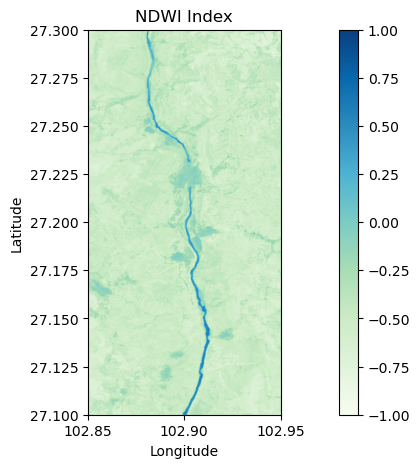

2018-10-01


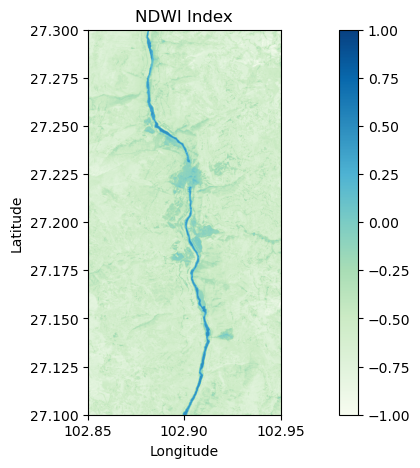

2019-01-01


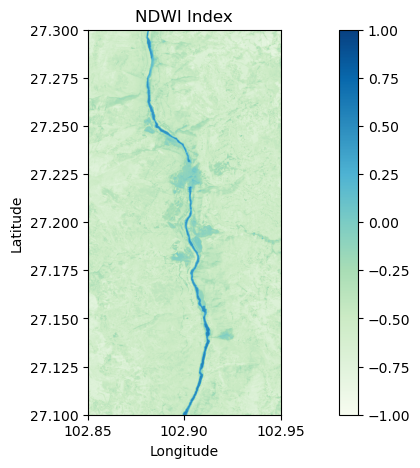

2019-04-01


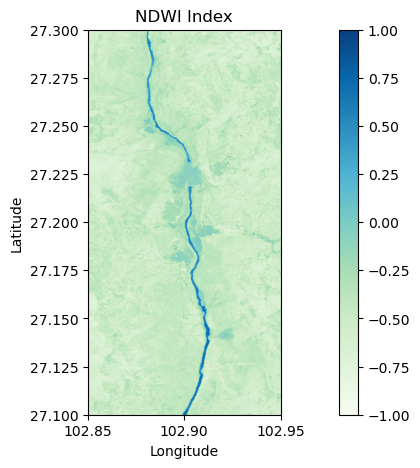

2019-07-01


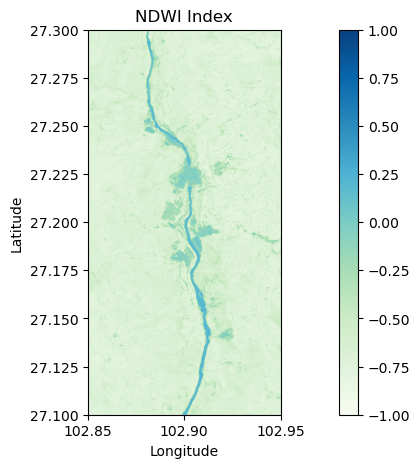

2019-10-01


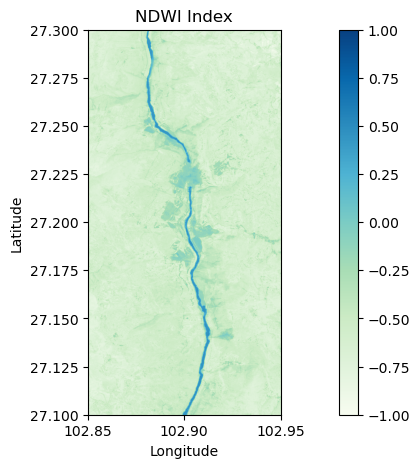

2020-01-01


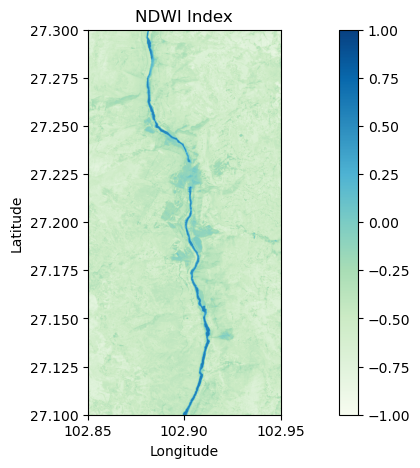

2020-04-01


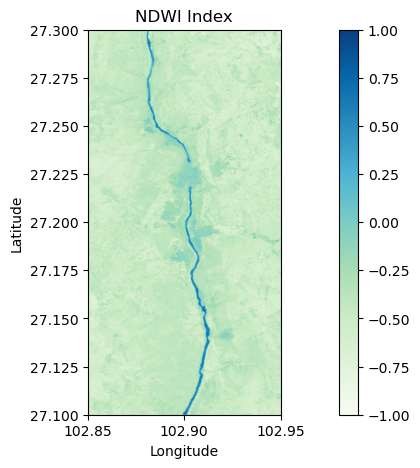

2020-07-01


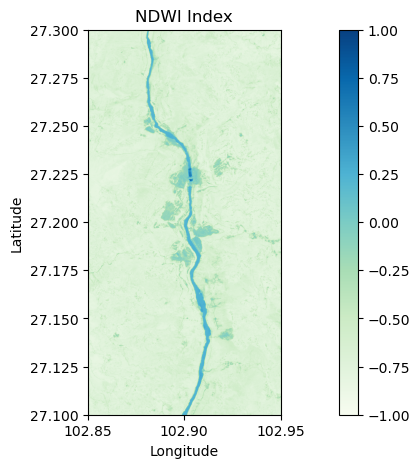

2020-10-01


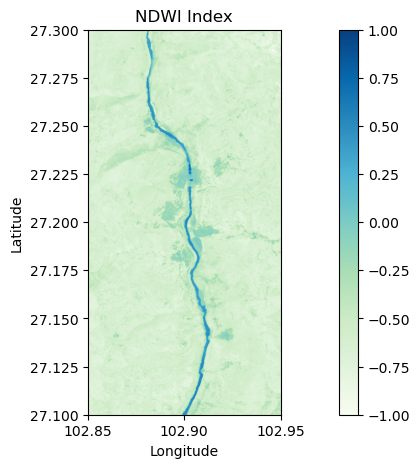

2021-01-01


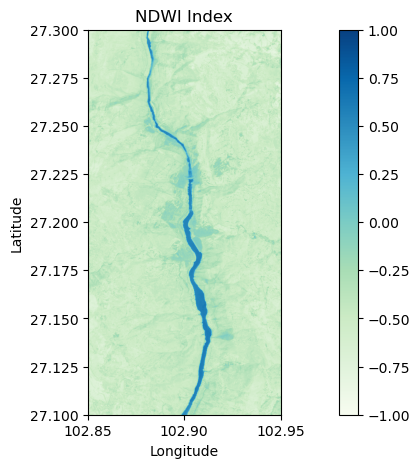

2021-04-01


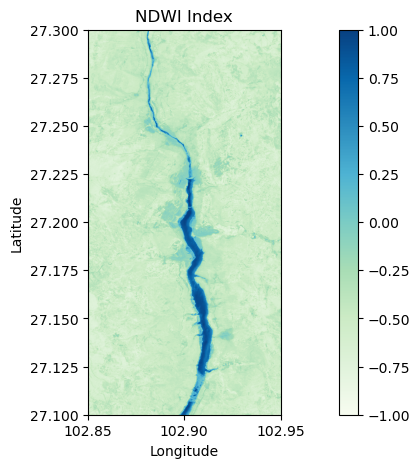

2021-07-01


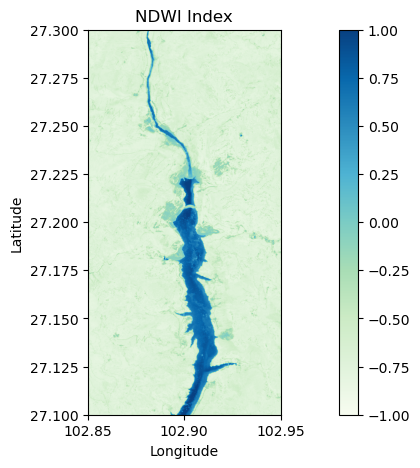

2021-10-01


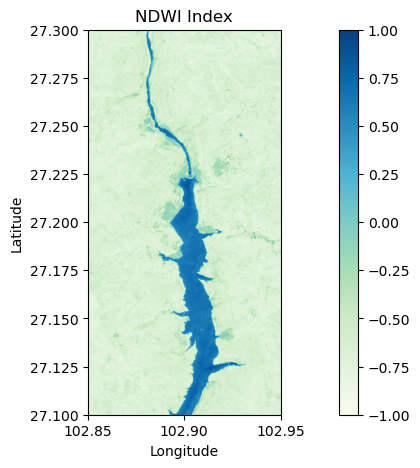

2022-01-01


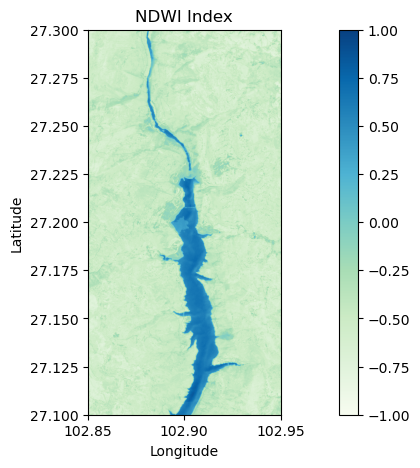

2022-04-01


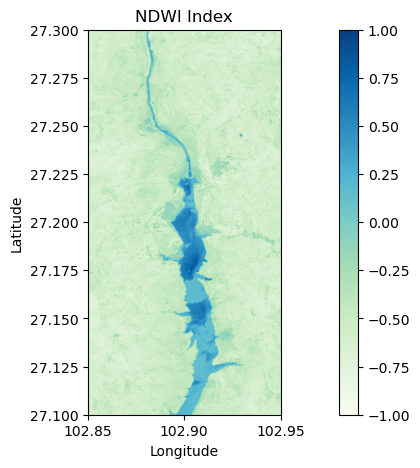

2022-07-01


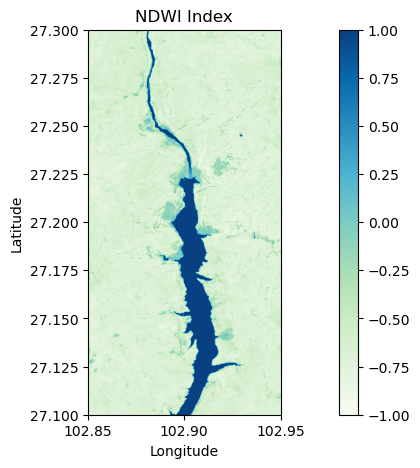

2022-10-01


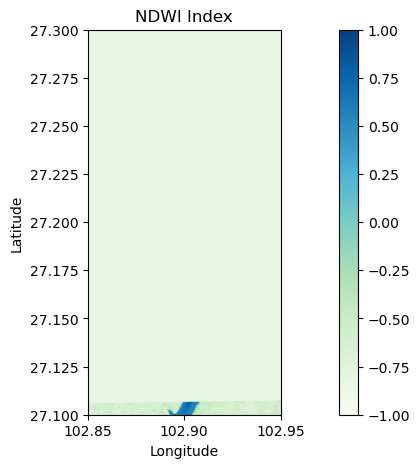

2023-01-01


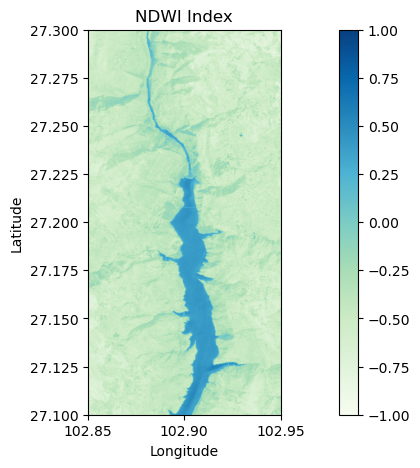

2023-04-01


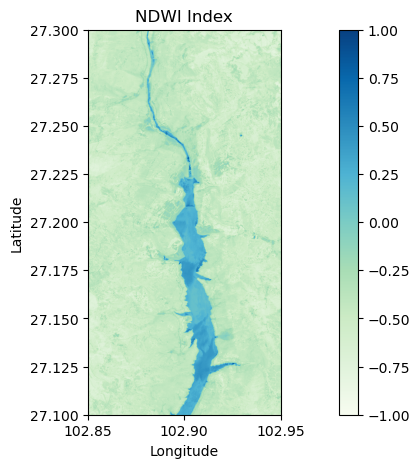

2023-07-01


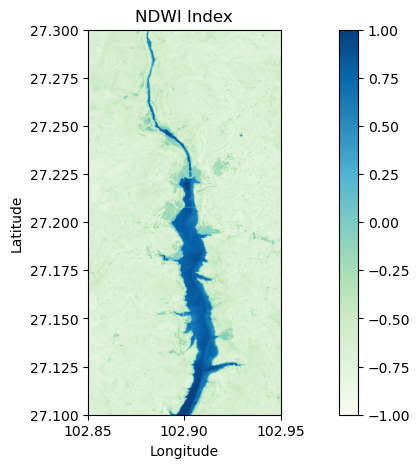

2023-10-01


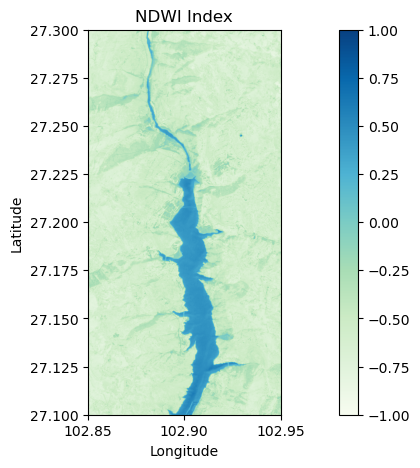

2024-01-01


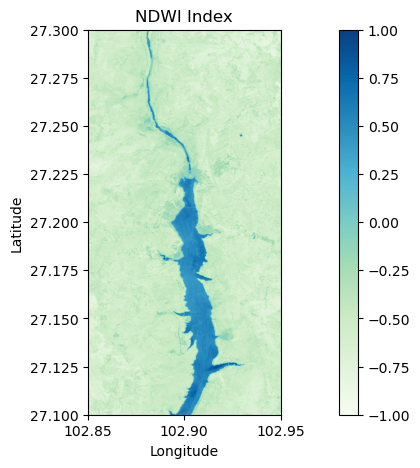

2024-04-01


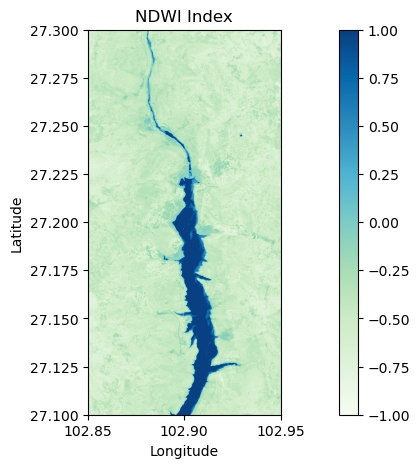

2024-07-01


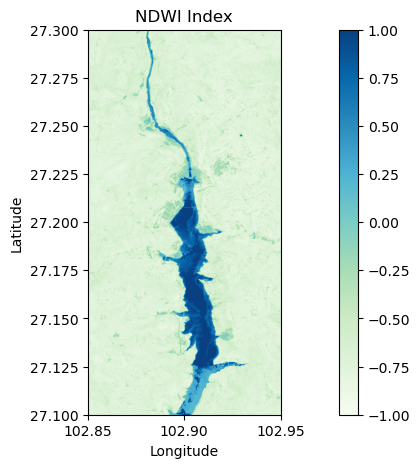

2024-10-01


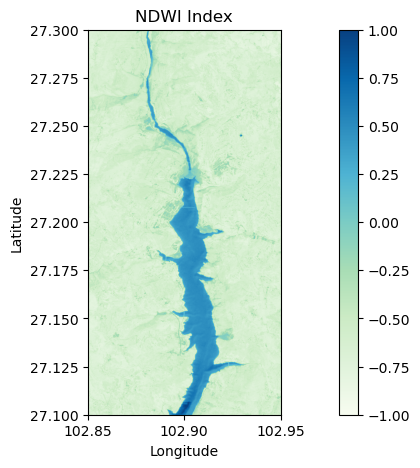

In [8]:
#Plot the NDWI band for every date, will help identify if any quarters had insufficent data
for date in range(0, len(ordered_damdata.keys())):
    print(list(ordered_damdata.keys())[date])
    plot_band(ordered_damdata[list(ordered_damdata.keys())[date]]['NDWI'].values, 'NDWI', 'GnBu')

In [9]:
#Removes the quarter where the data is insufficient
ordered_damdata.pop('2022-10-01')

,Longitude,Latitude,Blue,Green,Red,NIR,NDVI,NDWI,NDSSI,NSMI
0,102.849958,27.300026,0.0000,0.0000,0.0000,0.0000,0.000000,-0.822553,0.000000,0.000000
1,102.850048,27.300026,0.0000,0.0000,0.0000,0.0000,0.000000,-0.822553,0.000000,0.000000
2,102.850138,27.300026,0.0000,0.0000,0.0000,0.0000,0.000000,-0.822553,0.000000,0.000000
3,102.850228,27.300026,0.0000,0.0000,0.0000,0.0000,0.000000,-0.822553,0.000000,0.000000
4,102.850318,27.300026,0.0000,0.0000,0.0000,0.0000,0.000000,-0.822553,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
2484215,102.949671,27.099971,0.0234,0.0264,0.0179,0.0992,0.694278,-0.579618,-0.618271,0.308715
2484216,102.949761,27.099971,0.0234,0.0264,0.0179,0.0992,0.694278,-0.579618,-0.618271,0.308715
2484217,102.949851,27.099971,0.0231,0.0346,0.0159,0.0968,0.717835,-0.473364,-0.614679,0.372283
2484218,102.949941,27.099971,0.0224,0.0406,0.0200,0.1014,0.670511,-0.428169,-0.638126,0.460241


In [10]:
#Data that should show how the dam construction has affected the river
difference_damdata = {
    'Longitude': ordered_damdata[list(ordered_damdata.keys())[0]]['Longitude'].values,
    'Latitude': ordered_damdata[list(ordered_damdata.keys())[0]]['Latitude'].values,
    'NDWI': (ordered_damdata[list(ordered_damdata.keys())[0]]['NDWI'].values - 
             ordered_damdata[list(ordered_damdata.keys())[-1]]['NDWI'].values)
}
difference_damdata

{'Longitude': array([102.84995843, 102.85004826, 102.85013809, ..., 102.94985108,
        102.94994092, 102.95003075]),
 'Latitude': array([27.30002606, 27.30002606, 27.30002606, ..., 27.09997125,
        27.09997125, 27.09997125]),
 'NDWI': array([ 0.07467788,  0.06494543,  0.06753794, ..., -0.01285913,
        -0.15041701, -0.05388718])}

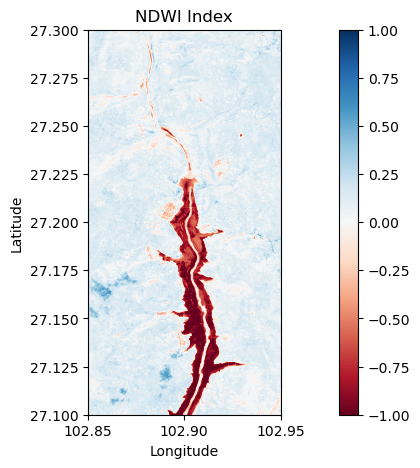

In [11]:
#Shows the displacement in water between first and last date
plot_band(difference_damdata['NDWI'], 'NDWI', 'RdBu')

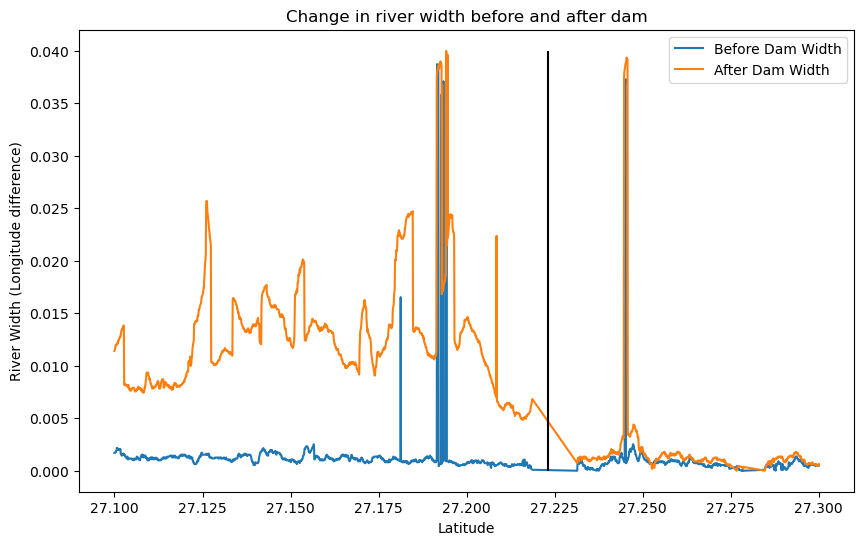

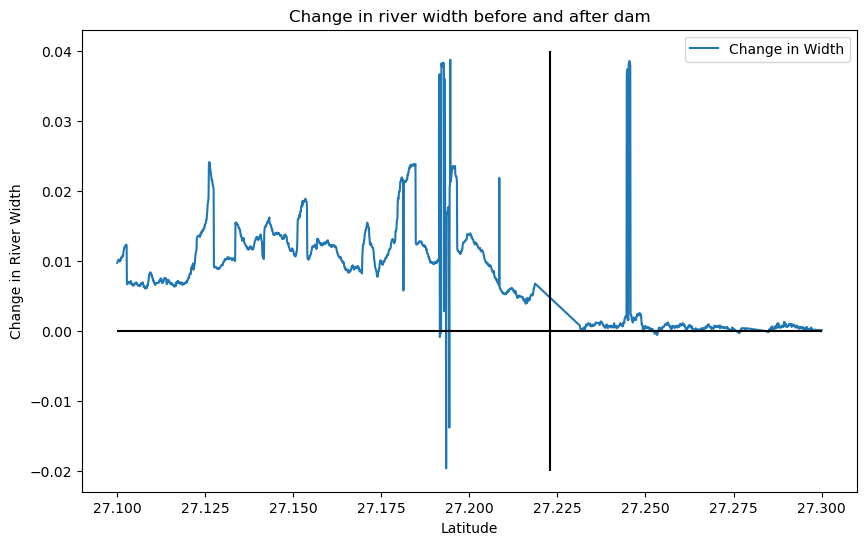

t-statistic: -51.085374897756125
p-value: 0.0
Reject the null hypothesis: Significant change in river width due to dam construction.


In [12]:
#Exploratory analysis as to whether the width of the 
dataset1 = ordered_damdata[list(ordered_damdata.keys())[0]]
dataset2 = ordered_damdata[list(ordered_damdata.keys())[-1]]

#Filter rows where NDWI > 0.25 (Assumption that this is water)
dataset1_water = dataset1[dataset1['NDWI'] > 0.25]
dataset2_water = dataset2[dataset2['NDWI'] > 0.25]

#Function to calculate the river width at each latitude
def calculate_width(dataset):
    width_at_lat = []
    
    for lat in np.unique(dataset['Latitude']):
        #Filters data for current latitude
        lat_data = dataset[dataset['Latitude'] == lat]
        
        #Calculates min and max longitude where NDWI > 0.25
        min_long = lat_data['Longitude'].min()
        max_long = lat_data['Longitude'].max()
        
        #Calculate widths (Difference between max and min longitude)
        width_at_lat.append((lat, max_long - min_long))
    
    return pd.DataFrame(width_at_lat, columns=['Latitude', 'Width'])

#Calculates widths for both datasets
widths1 = calculate_width(dataset1_water)
widths2 = calculate_width(dataset2_water)

#Merges datasets on Latitude to compare widths
merged = pd.merge(widths1, widths2, on='Latitude', suffixes=(' First', ' Last'))

# Calculate the change in river width
merged['Width Change'] = merged['Width Last'] - merged['Width First']

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(merged['Latitude'], merged['Width First'], label='Before Dam Width')
plt.plot(merged['Latitude'], merged['Width Last'], label='After Dam Width')
plt.xlabel('Latitude')
plt.ylabel('River Width (Longitude difference)')
plt.vlines(27.223,0,0.04,color='black')
plt.legend()
plt.title('Change in river width before and after dam')
plt.show()

# Plot the change in river width
plt.figure(figsize=(10, 6))
plt.plot(merged['Latitude'], merged['Width Change'], label='Change in Width')
plt.xlabel('Latitude')
plt.ylabel('Change in River Width')
plt.vlines(27.223,-0.02,0.04,color='black')
plt.hlines(0,27.1,27.3,color='black')
plt.legend()
plt.title('Change in river width before and after dam')
plt.show()

#Hypothesis test, Null Hypothesis: River has not significantly changed in width since the construction of the dam

#Find shared latitudes
shared_latitudes = list(set(widths1['Latitude']).intersection(set(widths2['Latitude'])))

#Filter by shared latitudes
widths1 = widths1[widths1['Latitude'].isin(shared_latitudes)]
widths2 = widths2[widths2['Latitude'].isin(shared_latitudes)]

#Paired t-test
t_stat, p_value = stats.ttest_rel(widths1['Width'], widths2['Width'])

#Results
print("t-statistic:", t_stat) #Will show widths are significantly larger after dam construction
print("p-value:", p_value) #Will show the difference in widths is highly statistically significant

#Significance of the results
if p_value < 0.05:
    print("Reject the null hypothesis: Significant change in river width due to dam construction.")
else:
    print("Fail to reject the null hypothesis: No significant change in river width.")

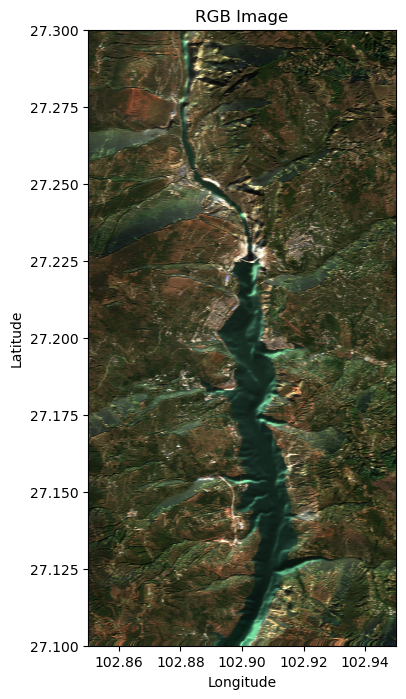

In [13]:
#Longitude and Latitude data
longitude = ordered_damdata[list(ordered_damdata.keys())[-1]]['Longitude'].values
latitude = ordered_damdata[list(ordered_damdata.keys())[-1]]['Latitude'].values

#RGB values corresponding to each longitude and latitude
red = ordered_damdata[list(ordered_damdata.keys())[-1]]['Red'].values #Red
green = ordered_damdata[list(ordered_damdata.keys())[-1]]['Green'].values #Green
blue = ordered_damdata[list(ordered_damdata.keys())[-1]]['Blue'].values #Blue

#Convert to RGB values and stack the colours
rgb_values = np.column_stack((red, green, blue)) *5 #Multiply by the value that offers the best visual distinction
rgb_values = np.clip(rgb_values, 0, 1) #Will reduce values >1 to 1 ensuring values between 0 and 1

#Scatter plot with rgb colours
plt.figure(figsize=(8,8))
plt.scatter(longitude, latitude, c=rgb_values)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('RGB Image')
plt.gca().set_aspect('equal')
plt.xlim(102.85, 102.95)
plt.ylim(27.10, 27.30)

plt.show()

Height = 1115, Width = 2228

In [14]:
#Creates a copy of sepecific data frame
damdata_copy = ordered_damdata[list(ordered_damdata.keys())[-1]].copy()
#Adds columns to identify water
damdata_copy['Water'] = damdata_copy['NDWI'].apply(lambda x: 1 if x > 0 else 0)
damdata_copy['Water_Alt'] = damdata_copy['NDWI'].apply(lambda x: 1 if x > 0.2 else 0)
#Displays the modified data frame
damdata_copy

,Longitude,Latitude,Blue,Green,Red,NIR,NDVI,NDWI,NDSSI,NSMI,Water,Water_Alt
0,102.849958,27.300026,0.02015,0.03505,0.02815,0.17970,0.729132,-0.673574,-0.798349,0.516497,0,0
1,102.850048,27.300026,0.01870,0.03345,0.02290,0.19565,0.790437,-0.707988,-0.825519,0.501666,0,0
2,102.850138,27.300026,0.01925,0.03325,0.02430,0.18840,0.771509,-0.699977,-0.814592,0.498698,0,0
3,102.850228,27.300026,0.01925,0.03325,0.02430,0.18840,0.771509,-0.699977,-0.814592,0.498698,0,0
4,102.850318,27.300026,0.02505,0.03745,0.03665,0.16370,0.634140,-0.627641,-0.734570,0.494705,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2484215,102.949671,27.099971,0.02260,0.02260,0.02460,0.08900,0.566901,-0.594982,-0.594982,0.352436,0,0
2484216,102.949761,27.099971,0.02260,0.02260,0.02460,0.08900,0.566901,-0.594982,-0.594982,0.352436,0,0
2484217,102.949851,27.099971,0.03450,0.02210,0.02500,0.09740,0.591503,-0.630126,-0.476876,0.154412,0,0
2484218,102.949941,27.099971,0.02360,0.03390,0.01720,0.10460,0.717570,-0.510469,-0.631825,0.368139,0,0


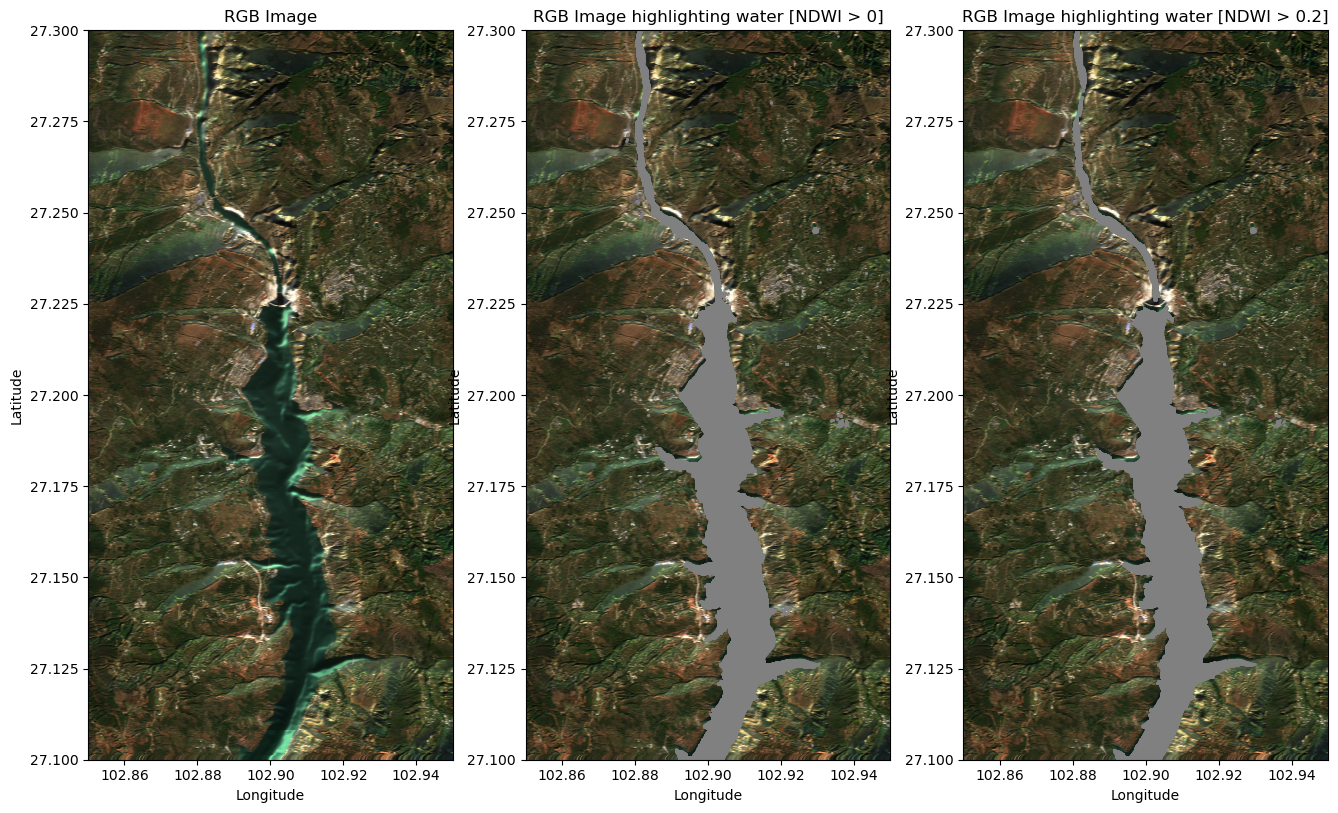

In [15]:
#Longitude and Latitude data
longitude = damdata_copy['Longitude']
latitude = damdata_copy['Latitude']

#RGB values corresponding to each longitude and latitude
red = damdata_copy['Red'] #Red
green = damdata_copy['Green'] #Green
blue = damdata_copy['Blue'] #Blue

#Water boolean values corresponding to each longitude and latitude
water = damdata_copy['Water']
water_alt = damdata_copy['Water_Alt']

#Convert to RGB values and stack the colours
rgb_values = np.column_stack((red, green, blue)) *5 #Multiply by the value that offers the best visual distinction
rgb_values = np.clip(rgb_values, 0, 1) #Will reduce values >1 to 1 ensuring values between 0 and 1

#Using subplots to create 3 figures
fig, axs = plt.subplots(1, 3,figsize=(16,16))

#Scatter plot with rgb colours
axs[0].scatter(longitude, latitude, c=rgb_values)
axs[0].set_xlabel('Longitude')
axs[0].set_ylabel('Latitude')
axs[0].set_title('RGB Image')
axs[0].set_aspect('equal')
axs[0].set_xlim(102.85, 102.95)
axs[0].set_ylim(27.10, 27.30)

#Scatter plot with rgb colours
axs[1].scatter(longitude, latitude, c=rgb_values)
axs[1].scatter(longitude[water == 1], latitude[water == 1], c='grey',s=1)
axs[1].set_xlabel('Longitude')
axs[1].set_ylabel('Latitude')
axs[1].set_title('RGB Image highlighting water [NDWI > 0]')
axs[1].set_aspect('equal')
axs[1].set_xlim(102.85, 102.95)
axs[1].set_ylim(27.10, 27.30)

#Scatter plot with rgb colours
axs[2].scatter(longitude, latitude, c=rgb_values)
axs[2].scatter(longitude[water_alt == 1], latitude[water_alt == 1], c='grey',s=1)
axs[2].set_xlabel('Longitude')
axs[2].set_ylabel('Latitude')
axs[2].set_title('RGB Image highlighting water [NDWI > 0.2]')
axs[2].set_aspect('equal')
axs[2].set_xlim(102.85, 102.95)
axs[2].set_ylim(27.10, 27.30)

plt.show()

In [16]:
#Creates a copy of the entire data frame
damdata_copies = {key: value.copy() for key, value in ordered_damdata.items()}
for date, df in damdata_copies.items():
    #Adds column to identify water in each specific data frame
    df['Is_water'] = df['NDWI'].apply(lambda x: 1 if x > 0.2 else 0)

In [17]:
#Get the data for the last image
date, df = list(damdata_copies.items())[-1]

#Extract RGB and Is_water columns
image_data = df[['Red', 'Green', 'Blue']].values
is_water_data = df['Is_water'].values

In [18]:
#Set parameters
flip_prob=0.5
rotation_range=(-180, 180)

#Define data augmentation transformations
def transform_pair(image1, image2):
    #Apply horizontal flip to both images with 50% probability
    if random.random() < flip_prob: #Random value between 0 and 1
        image1 = transforms.functional.hflip(image1)
        image2 = transforms.functional.hflip(image2)
    
    #Apply the same random rotation to both images
    rotation_angle = random.uniform(*rotation_range)  # Random angle between -180 and 180
    image1 = transforms.functional.rotate(image1, rotation_angle)
    image2 = transforms.functional.rotate(image2, rotation_angle)
    
    return image1, image2

#Define colour jitter transformation (apply only to image_data)
colour_jitter = transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1)

In [19]:
#Convert to best visual distinction
image_data = image_data * 5
image_data = np.clip(image_data, 0, 1)

#Information about the data
print(image_data)
min_pixel_value = image_data.min()
max_pixel_value = image_data.max()
print(f"Minimum pixel value: {min_pixel_value}")
print(f"Maximum pixel value: {max_pixel_value}")

[[0.14075 0.17525 0.10075]
 [0.1145  0.16725 0.0935 ]
 [0.1215  0.16625 0.09625]
 ...
 [0.125   0.1105  0.1725 ]
 [0.086   0.1695  0.118  ]
 [0.07    0.136   0.166  ]]
Minimum pixel value: 0.0
Maximum pixel value: 1.0


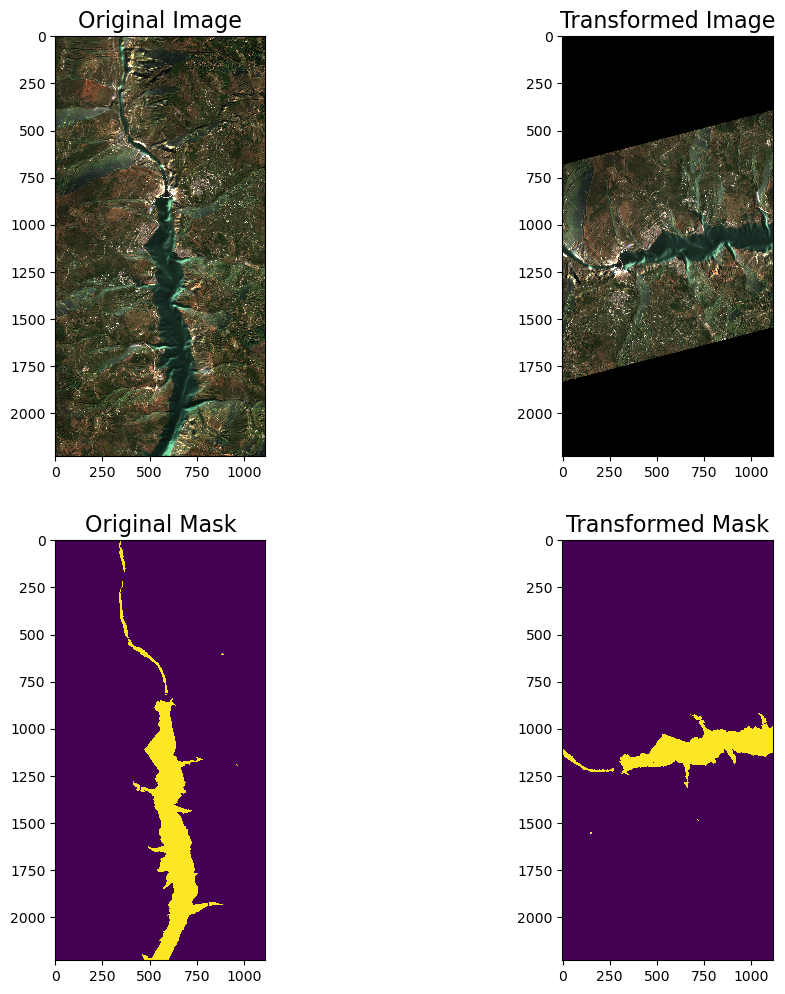

In [20]:
#Scale the data to range [0, 255]
image_data = (image_data * 255).astype(np.uint8)
image_data = image_data.reshape(2228,1115, 3)
is_water_data = (is_water_data * 255).astype(np.uint8)
is_water_data = is_water_data.reshape(2228,1115)

#Convert the NumPy array to a PIL image
pil_image_data = Image.fromarray(image_data)
pil_is_water_data = Image.fromarray(is_water_data)

#Apply the transformations to the image and mask
trans_image_data = colour_jitter(pil_image_data) #Colour jitter only applied to the image
trans_image_data, trans_is_water_data = transform_pair(trans_image_data, pil_is_water_data)

#Plot the images side by side
fig, axes = plt.subplots(2, 2, figsize=(12,12))

#Display images and masks
axes[0, 0].imshow(np.array(pil_image_data), interpolation='none')  # Original Image
axes[0, 1].imshow(np.array(trans_image_data), interpolation='none')  # Transformed Image
axes[1, 0].imshow(np.array(pil_is_water_data), interpolation='none')  # Original Mask
axes[1, 1].imshow(np.array(trans_is_water_data), interpolation='none')  # Transformed Mask

#Set titles and hide axes
axes[0, 0].set_title("Original Image", fontsize=16)
axes[0, 1].set_title("Transformed Image", fontsize=16)
axes[1, 0].set_title("Original Mask", fontsize=16)
axes[1, 1].set_title("Transformed Mask", fontsize=16)

plt.show()

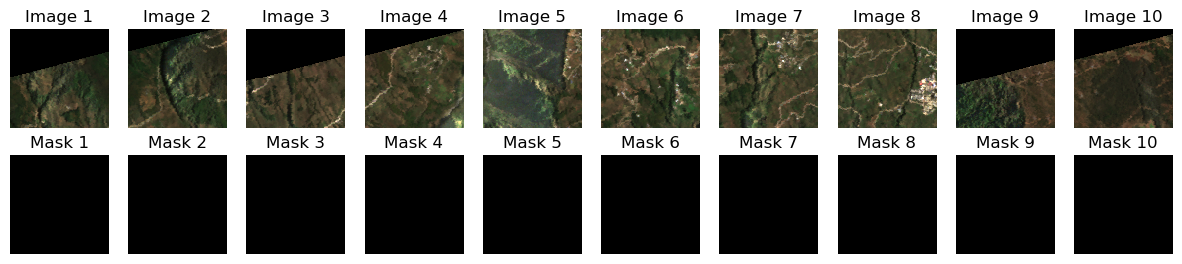

In [21]:
#Split an image into 100x100 patches and exclude 0,0,0 slices
def slice(image, mask, slice_size=100, null_threshold=25): #Arbitary threshold to remove slices with significant 0,0,0
    width, height = image.size
    image_slices = []
    mask_slices = []

    for top in range(0, height, slice_size):
        for left in range(0, width, slice_size):
            #Define the box to crop the image
            box = (left, top, min(left + slice_size, width), min(top + slice_size, height))
            slice_image = image.crop(box)
            slice_mask = mask.crop(box)

            #Check if the patch has meaningful content (Average pixel above threshold) and 100x100 pixels
            if not is_zero_slice(slice_image, null_threshold) and slice_image.size == (slice_size, slice_size):
                image_slices.append(slice_image)
                mask_slices.append(slice_mask)
    
    return image_slices, mask_slices

#Determine if a slice is meaningless
def is_zero_slice(slice_image, threshold):
    # Convert the patch to a numpy array and compute the average pixel value
    slice_np = np.array(slice_image)
    
    # For RGB image, check if the average pixel value across all channels is close to zero
    avg_pixel_value = np.mean(slice_np)
    
    return avg_pixel_value < threshold

#Split the transformed images and masks into 100x100 slices
image_slices, mask_slices = slice(trans_image_data, trans_is_water_data, slice_size=100)

#Visualize the first 10 slices
fig, axes = plt.subplots(2, 10, figsize=(15, 3))  # Adjust to show more patches

#Display the first 10 slices of the image
for i, ax in enumerate(axes[0]):
    ax.imshow(image_slices[i], interpolation='none')
    ax.set_title(f"Image {i+1}")
    ax.set_axis_off()

#Display the first 10 slices of the mask
for i, ax in enumerate(axes[1]):
    ax.imshow(mask_slices[i], cmap='gray', interpolation='none')
    ax.set_title(f"Mask {i+1}")
    ax.set_axis_off()

plt.show()